✅ Best Params: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
📏 RMSE: 0.6034489607162036
📊 R² Score: 0.72210916268423


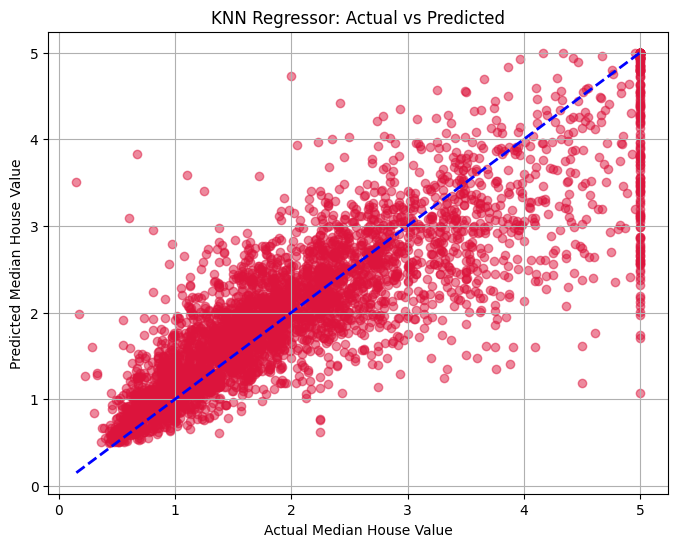

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Load real-world California housing dataset
data = fetch_california_housing()
X = data.data
y = data.target  # Median house value
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Grid search for best K
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
knn_reg = KNeighborsRegressor()
grid = GridSearchCV(knn_reg, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train_scaled, y_train)
print("✅ Best Params:", grid.best_params_)
best_knn = grid.best_estimator_
# Predict and evaluate
y_pred = best_knn.predict(X_test_scaled)
print("📏 RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("📊 R² Score:", r2_score(y_test, y_pred))
# Plot predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, c='crimson')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'b--', lw=2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("KNN Regressor: Actual vs Predicted")
plt.grid(True)
plt.show()